# Intro

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 23.7 MB/s eta 0:00:00


In [ ]:
# ============================================================================
# COMPREHENSIVE CATBOOST HYPERPARAMETER TUNING - OPTIMIZED VERSION
# ============================================================================

# Import all necessary libraries
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import time
from datetime import datetime
import itertools
import pickle
import joblib
import json

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)

# CatBoost
from catboost import CatBoostClassifier, Pool

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
plt.style.use('default')

print("="*80)
print("OPTIMIZED CATBOOST HYPERPARAMETER TUNING PIPELINE")
print("="*80)
print("✅ All libraries imported successfully!")

OPTIMIZED CATBOOST HYPERPARAMETER TUNING PIPELINE
✅ All libraries imported successfully!


# Train

In [ ]:
# ============================================================================
# CONFIGURATION - UPDATE THESE PARAMETERS FOR YOUR DATASET
# ============================================================================

# Dataset configuration
CSV_FILE_PATH = "/content/combined_dataset.csv"  # 👈 CHANGE THIS TO YOUR CSV FILE PATH
TARGET_COLUMN = "label"  # Set to None to use last column, or specify column name like "class"
COLUMNS_TO_DROP = ['file_name', 'aspect_ratio', 'resolution']  # 👈 SPECIFY COLUMNS TO DROP (or set to [] for none)

# Training configuration
TEST_SIZE = 0.3  # 70% train, 30% test
RANDOM_STATE = 420
USE_GPU = False  # Set to False if you don't want to use GPU

# Hyperparameter tuning configuration
MAX_COMBINATIONS = 50  # Maximum number of hyperparameter combinations to test
EARLY_STOPPING_ROUNDS = 20

# Model saving configuration
SAVE_PATH = "./best_catboost_model"

print("🔧 Configuration loaded:")
print(f"  📁 Dataset: {CSV_FILE_PATH}")
print(f"  🎯 Target column: {TARGET_COLUMN or 'Last column'}")
print(f"  🗑️ Columns to drop: {COLUMNS_TO_DROP}")
print(f"  📊 Test size: {TEST_SIZE}")
print(f"  🖥️ Use GPU: {USE_GPU}")


🔧 Configuration loaded:
  📁 Dataset: /content/combined_dataset.csv
  🎯 Target column: class
  🗑️ Columns to drop: ['file_name', 'aspect_ratio', 'resolution']
  📊 Test size: 0.1
  🖥️ Use GPU: True


In [ ]:
# ============================================================================
# DATA LOADING AND PREPROCESSING FUNCTIONS
# ============================================================================

def load_and_preprocess_data(file_path, target_column_name=None, columns_to_drop=None):
    """
    Load CSV data and perform optimized preprocessing for numerical features
    """
    print("\n📁 LOADING DATASET...")

    try:
        # Load the dataset
        df = pd.read_csv(file_path)
        print(f"✅ Dataset loaded successfully!")
        print(f"📊 Dataset shape: {df.shape}")
        print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

        # Display basic info
        print(f"\n🔢 Column data types:")
        dtype_counts = df.dtypes.value_counts()
        for dtype, count in dtype_counts.items():
            print(f"  {dtype}: {count} columns")

        # Drop specified columns
        if columns_to_drop:
            original_cols = df.shape[1]
            df = df.drop(columns=columns_to_drop, errors='ignore')
            dropped = original_cols - df.shape[1]
            if dropped > 0:
                print(f"🗑️ Dropped {dropped} columns")

        # Handle target variable (assume last column if not specified)
        if target_column_name is None:
            target_column_name = df.columns[-1]

        print(f"🎯 Target variable: '{target_column_name}'")

        # Separate features and target
        X = df.drop(target_column_name, axis=1)
        y = df[target_column_name]

        print(f"🎯 Target distribution:\n{y.value_counts()}")

        # CRITICAL OPTIMIZATION: Convert numerical features to float32
        print(f"\n🚀 OPTIMIZING NUMERICAL FEATURES...")
        numerical_cols = X.select_dtypes(include=[np.number]).columns
        if len(numerical_cols) > 0:
            # Convert float64 to float32 for massive performance improvement
            float64_cols = X.select_dtypes(include=[np.float64]).columns
            if len(float64_cols) > 0:
                print(f"⚡ Converting {len(float64_cols)} columns from float64 to float32...")
                X[float64_cols] = X[float64_cols].astype(np.float32)

            # Keep int columns as they are (CatBoost handles them efficiently)
            print(f"✅ Numerical features optimized: {len(numerical_cols)} columns")

        # Handle missing values efficiently
        print(f"\n🔧 HANDLING MISSING VALUES...")
        missing_info = X.isnull().sum()
        if missing_info.sum() > 0:
            print(f"⚠️ Found missing values in {(missing_info > 0).sum()} columns")
            # For numerical columns, fill with median (efficient for CatBoost)
            for col in X.select_dtypes(include=[np.number]).columns:
                if X[col].isnull().sum() > 0:
                    X[col].fillna(X[col].median(), inplace=True)
            # For object columns, fill with 'Unknown'
            for col in X.select_dtypes(include=['object']).columns:
                if X[col].isnull().sum() > 0:
                    X[col].fillna('Unknown', inplace=True)
            print("✅ Missing values handled")
        else:
            print("✅ No missing values found")

        # Final memory optimization check
        final_memory = X.memory_usage(deep=True).sum() / 1024**2
        print(f"💾 Final memory usage: {final_memory:.2f} MB")

        return X, y, target_column_name

    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return None, None, None

def encode_target_if_needed(y):
    """
    Encode target variable if it's categorical
    """
    if y.dtype == 'object' or y.dtype.name == 'category':
        print(f"\n🔄 Encoding categorical target variable...")
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f"✅ Target classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
        return y_encoded, le
    else:
        print(f"\n✅ Target variable is already numerical")
        return y, None


In [ ]:
# ============================================================================
# HYPERPARAMETER GRID OPTIMIZED FOR NUMERICAL FEATURES
# ============================================================================

def create_optimized_hyperparameter_grid(max_combinations=50):
    """
    Create hyperparameter grid optimized for numerical features
    """
    print(f"\n⚙️ CREATING OPTIMIZED HYPERPARAMETER GRID...")

    # Optimized parameters for numerical features (like ResNet features)
    param_grid = {
        'iterations': [200, 300, 500, 700],  # Sufficient for most numerical datasets
        'learning_rate': [0.01, 0.03, 0.05, 0.1],  # Conservative range for stability
        'depth': [6, 7, 8, 9, 10],  # Optimal depth range for numerical features
        'l2_leaf_reg': [1, 3, 5, 10, 15],  # Important regularization for high-dim data
        'border_count': [128, 200, 254],  # Key parameter for numerical splits
        'random_strength': [0, 1, 5],  # Helps with overfitting
        'bagging_temperature': [0, 1],  # Simplified for efficiency
        'subsample': [0.8, 0.9, 1.0],  # Essential for high-dimensional data
        'colsample_bylevel': [0.8, 0.9, 1.0],  # Feature sampling
        'min_data_in_leaf': [1, 5, 10],  # Prevent overfitting
    }

    print("🔄 Generating parameter combinations...")

    # Generate combinations more efficiently
    param_combinations = []
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    # Use itertools to generate all combinations
    all_combinations = list(itertools.product(*values))

    # Randomly sample if too many combinations
    if len(all_combinations) > max_combinations:
        print(f"⚠️ Total combinations: {len(all_combinations)}. Sampling {max_combinations} combinations.")
        np.random.seed(RANDOM_STATE)
        selected_indices = np.random.choice(len(all_combinations), max_combinations, replace=False)
        sampled_combinations = [all_combinations[i] for i in selected_indices]
    else:
        sampled_combinations = all_combinations

    # Convert to list of dictionaries
    for combination in sampled_combinations:
        param_dict = dict(zip(keys, combination))
        param_combinations.append(param_dict)

    print(f"✅ Created {len(param_combinations)} hyperparameter combinations")
    return param_combinations


In [ ]:
# ============================================================================
# MODEL TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def evaluate_model_comprehensive(y_true, y_pred, y_pred_proba=None):
    """
    Comprehensive model evaluation with all relevant metrics
    """
    results = {}

    # Basic classification metrics
    results['accuracy'] = accuracy_score(y_true, y_pred)
    results['precision'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    results['recall'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    results['f1_score'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    results['matthews_corrcoef'] = matthews_corrcoef(y_true, y_pred)
    results['cohen_kappa'] = cohen_kappa_score(y_true, y_pred)

    # Confusion Matrix
    results['confusion_matrix'] = confusion_matrix(y_true, y_pred)

    # ROC AUC (if binary classification and probabilities available)
    if y_pred_proba is not None and len(np.unique(y_true)) == 2:
        try:
            results['roc_auc'] = roc_auc_score(y_true, y_pred_proba[:, 1])
        except:
            results['roc_auc'] = None
    elif y_pred_proba is not None and len(np.unique(y_true)) > 2:
        try:
            results['roc_auc'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')
        except:
            results['roc_auc'] = None
    else:
        results['roc_auc'] = None

    return results

def train_and_evaluate_catboost(X_train, X_test, y_train, y_test, params, model_name, use_gpu=False):
    """
    Train CatBoost model with optimized settings for numerical features
    """
    try:
        # Configure for GPU/CPU
        if use_gpu:
            params_copy = params.copy()
            params_copy['task_type'] = 'GPU'
            params_copy['devices'] = '0'
        else:
            params_copy = params.copy()
            params_copy['task_type'] = 'CPU'

        # Initialize model with optimized settings
        model = CatBoostClassifier(
            **params_copy,
            random_seed=RANDOM_STATE,
            verbose=False,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            eval_metric='F1'
        )

        # Train model
        start_time = time.time()

        # Since we're not manually specifying categorical features,
        # CatBoost will auto-detect them from object/category dtypes
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            verbose=False
        )

        training_time = time.time() - start_time

        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)

        # Evaluate model
        results = evaluate_model_comprehensive(y_test, y_pred, y_pred_proba)
        results['training_time'] = training_time
        results['model'] = model
        results['params'] = params.copy()
        results['model_name'] = model_name
        results['feature_importance'] = model.get_feature_importance()

        return results

    except Exception as e:
        print(f"❌ Error training {model_name}: {str(e)}")
        return None

def check_gpu_availability():
    """
    Check if GPU is available for CatBoost
    """
    gpu_available = False
    gpu_info = "No GPU detected"

    if USE_GPU:
        try:
            # Try to create a simple GPU model to test availability
            test_model = CatBoostClassifier(
                iterations=1,
                task_type='GPU',
                devices='0',
                verbose=False
            )
            # Test with dummy data
            X_dummy = np.random.random((10, 5)).astype(np.float32)
            y_dummy = np.random.randint(0, 2, 10)
            test_model.fit(X_dummy, y_dummy, verbose=False)
            gpu_available = True
            gpu_info = "GPU available and tested successfully"
        except Exception as e:
            gpu_available = False
            gpu_info = f"GPU test failed: {str(e)}"

    print(f"🖥️ GPU Status: {gpu_info}")
    return gpu_available


In [ ]:
# ============================================================================
# RESULTS ANALYSIS AND VISUALIZATION
# ============================================================================

def create_results_dataframe(all_results):
    """
    Create comprehensive results DataFrame for analysis
    """
    results_data = []

    for i, result in enumerate(all_results):
        if result is not None:
            row = {
                'model_id': i,
                'model_name': result['model_name'],
                'accuracy': result['accuracy'],
                'precision': result['precision'],
                'recall': result['recall'],
                'f1_score': result['f1_score'],
                'balanced_accuracy': result['balanced_accuracy'],
                'matthews_corrcoef': result['matthews_corrcoef'],
                'cohen_kappa': result['cohen_kappa'],
                'roc_auc': result['roc_auc'],
                'training_time': result['training_time'],
                # Key hyperparameters
                'iterations': result['params'].get('iterations'),
                'learning_rate': result['params'].get('learning_rate'),
                'depth': result['params'].get('depth'),
                'l2_leaf_reg': result['params'].get('l2_leaf_reg'),
                'border_count': result['params'].get('border_count'),
                'subsample': result['params'].get('subsample'),
            }
            results_data.append(row)

    return pd.DataFrame(results_data)

def create_comprehensive_visualizations(results_df):
    """
    Create comprehensive results visualizations
    """
    print("\n📊 CREATING RESULTS VISUALIZATIONS...")

    # Set up the plotting area
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('CatBoost Hyperparameter Tuning Results Analysis', fontsize=16, fontweight='bold')

    # 1. F1 Score Distribution
    axes[0, 0].hist(results_df['f1_score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(results_df['f1_score'].mean(), color='red', linestyle='--',
                       label=f'Mean: {results_df["f1_score"].mean():.3f}')
    axes[0, 0].set_title('F1 Score Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('F1 Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Performance vs Training Time
    scatter = axes[0, 1].scatter(results_df['training_time'], results_df['f1_score'],
                                alpha=0.6, c=results_df['accuracy'], cmap='viridis', s=60)
    axes[0, 1].set_title('F1 Score vs Training Time', fontweight='bold')
    axes[0, 1].set_xlabel('Training Time (seconds)')
    axes[0, 1].set_ylabel('F1 Score')
    plt.colorbar(scatter, ax=axes[0, 1], label='Accuracy')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Learning Rate Impact
    lr_groups = results_df.groupby('learning_rate')['f1_score'].agg(['mean', 'std']).reset_index()
    axes[0, 2].errorbar(lr_groups['learning_rate'], lr_groups['mean'], yerr=lr_groups['std'],
                        marker='o', capsize=5, capthick=2, linewidth=2)
    axes[0, 2].set_title('Learning Rate vs F1 Score', fontweight='bold')
    axes[0, 2].set_xlabel('Learning Rate')
    axes[0, 2].set_ylabel('F1 Score (Mean ± Std)')
    axes[0, 2].set_xscale('log')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Tree Depth Analysis
    depth_data = [results_df[results_df['depth'] == d]['f1_score'].values
                  for d in sorted(results_df['depth'].unique()) if len(results_df[results_df['depth'] == d]) > 0]
    axes[1, 0].boxplot(depth_data, labels=sorted(results_df['depth'].unique()))
    axes[1, 0].set_title('Tree Depth vs F1 Score Distribution', fontweight='bold')
    axes[1, 0].set_xlabel('Tree Depth')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Border Count vs Performance
    axes[1, 1].scatter(results_df['border_count'], results_df['f1_score'],
                       alpha=0.6, c=results_df['l2_leaf_reg'], cmap='plasma', s=60)
    axes[1, 1].set_title('Border Count vs F1 Score', fontweight='bold')
    axes[1, 1].set_xlabel('Border Count')
    axes[1, 1].set_ylabel('F1 Score')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Top Models Performance Comparison
    top_10 = results_df.nlargest(10, 'f1_score')
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    x_pos = np.arange(len(top_10))

    width = 0.2
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']

    for i, metric in enumerate(metrics):
        axes[1, 2].bar(x_pos + i*width, top_10[metric], width,
                       label=metric.title(), color=colors[i], alpha=0.8)

    axes[1, 2].set_title('Top 10 Models - Performance Metrics', fontweight='bold')
    axes[1, 2].set_xlabel('Model Rank')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].legend()
    axes[1, 2].set_xticks(x_pos + width * 1.5)
    axes[1, 2].set_xticklabels([f'#{i+1}' for i in range(len(top_10))])
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_comprehensive_results(results_df, all_results):
    """
    Print detailed results analysis with best model information
    """
    print("\n" + "="*80)
    print("📊 COMPREHENSIVE RESULTS ANALYSIS")
    print("="*80)

    # Performance summary
    print("\n📈 OVERALL PERFORMANCE SUMMARY:")
    print("-" * 60)
    summary_metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'balanced_accuracy', 'matthews_corrcoef']
    summary_stats = results_df[summary_metrics].describe()
    print(summary_stats.round(4))

    # Top performing models
    print(f"\n🏆 TOP 10 BEST PERFORMING MODELS (Ranked by F1 Score):")
    print("-" * 60)
    top_10 = results_df.nlargest(10, 'f1_score')
    display_cols = ['model_name', 'f1_score', 'accuracy', 'precision', 'recall',
                   'balanced_accuracy', 'training_time', 'learning_rate', 'depth']
    print(top_10[display_cols].round(4).to_string(index=False))

    # Best model detailed analysis
    best_model_idx = results_df['f1_score'].idxmax()
    best_result = all_results[best_model_idx]

    print(f"\n🥇 CHAMPION MODEL DETAILED ANALYSIS:")
    print("=" * 50)
    print(f"🏷️  Model Name: {best_result['model_name']}")
    print(f"🎯 F1 Score: {best_result['f1_score']:.4f}")
    print(f"🎯 Accuracy: {best_result['accuracy']:.4f}")
    print(f"🎯 Precision: {best_result['precision']:.4f}")
    print(f"🎯 Recall: {best_result['recall']:.4f}")
    print(f"🎯 Balanced Accuracy: {best_result['balanced_accuracy']:.4f}")
    print(f"🎯 Matthews Correlation: {best_result['matthews_corrcoef']:.4f}")
    print(f"🎯 Cohen's Kappa: {best_result['cohen_kappa']:.4f}")
    if best_result['roc_auc'] is not None:
        print(f"🎯 ROC AUC: {best_result['roc_auc']:.4f}")
    print(f"⏱️  Training Time: {best_result['training_time']:.2f} seconds")

    print(f"\n🔧 OPTIMAL HYPERPARAMETERS:")
    print("-" * 30)
    for param, value in best_result['params'].items():
        if param not in ['task_type', 'devices']:
            print(f"  {param}: {value}")

    # Confusion matrix
    print(f"\n📋 CONFUSION MATRIX:")
    print("-" * 25)
    cm = best_result['confusion_matrix']
    print(cm)

    # Feature importance (top 20 features)
    if 'feature_importance' in best_result and best_result['feature_importance'] is not None:
        print(f"\n⭐ TOP 20 MOST IMPORTANT FEATURES:")
        print("-" * 40)
        feature_importance = best_result['feature_importance']
        if hasattr(feature_importance, '__len__') and len(feature_importance) > 0:
            # Get feature names if available (assuming they match the order)
            top_features = feature_importance.argsort()[-20:][::-1]
            for i, feat_idx in enumerate(top_features):
                print(f"  {i+1:2d}. Feature_{feat_idx:3d}: {feature_importance[feat_idx]:.4f}")

    return best_model_idx, best_result


In [ ]:
# ============================================================================
# MODEL SAVING AND LOADING FUNCTIONS
# ============================================================================

def save_champion_model(best_result, save_path=SAVE_PATH):
    """
    Save the champion model in multiple formats with comprehensive metadata
    """
    print(f"\n💾 SAVING CHAMPION MODEL...")

    # Create directory if it doesn't exist
    Path(save_path).mkdir(parents=True, exist_ok=True)

    # 1. Save using CatBoost native format (.cbm) - most efficient
    model_path = f"{save_path}/champion_catboost_model.cbm"
    best_result['model'].save_model(model_path)
    print(f"✅ CatBoost native model saved: {model_path}")

    # 2. Save using pickle for Python compatibility
    pickle_path = f"{save_path}/champion_catboost_model.pkl"
    with open(pickle_path, 'wb') as f:
        pickle.dump(best_result['model'], f)
    print(f"✅ Pickle model saved: {pickle_path}")

    # 3. Save using joblib for scientific computing
    joblib_path = f"{save_path}/champion_catboost_model.joblib"
    joblib.dump(best_result['model'], joblib_path)
    print(f"✅ Joblib model saved: {joblib_path}")

    # 4. Save comprehensive metadata
    metadata = {
        'model_info': {
            'model_name': best_result['model_name'],
            'model_type': 'CatBoostClassifier',
            'training_timestamp': datetime.now().isoformat(),
            'random_seed': RANDOM_STATE
        },
        'performance_metrics': {
            'f1_score': float(best_result['f1_score']),
            'accuracy': float(best_result['accuracy']),
            'precision': float(best_result['precision']),
            'recall': float(best_result['recall']),
            'balanced_accuracy': float(best_result['balanced_accuracy']),
            'matthews_corrcoef': float(best_result['matthews_corrcoef']),
            'cohen_kappa': float(best_result['cohen_kappa']),
            'roc_auc': float(best_result['roc_auc']) if best_result['roc_auc'] is not None else None,
            'training_time_seconds': float(best_result['training_time'])
        },
        'hyperparameters': {k: v for k, v in best_result['params'].items()
                          if k not in ['task_type', 'devices']},
        'data_info': {
            'test_size': TEST_SIZE,
            'columns_dropped': COLUMNS_TO_DROP,
            'target_column': TARGET_COLUMN
        },
        'feature_importance': best_result['feature_importance'].tolist() if 'feature_importance' in best_result else None
    }

    metadata_path = f"{save_path}/model_metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"✅ Model metadata saved: {metadata_path}")

In [ ]:
# ============================================================================
# MAIN EXECUTION PIPELINE
# ============================================================================

def execute_catboost_pipeline():
    """
    Execute the complete CatBoost hyperparameter tuning pipeline
    """
    print("🚀 STARTING OPTIMIZED CATBOOST HYPERPARAMETER TUNING PIPELINE")
    pipeline_start_time = time.time()

    # Step 1: Load and preprocess data
    print("\n" + "="*60)
    print("STEP 1: DATA LOADING AND PREPROCESSING")
    print("="*60)

    X, y, target_column = load_and_preprocess_data(CSV_FILE_PATH, TARGET_COLUMN, COLUMNS_TO_DROP)
    if X is None:
        print("❌ Pipeline failed at data loading stage")
        return None, None, None

    # Step 2: Encode target if needed
    y_encoded, label_encoder = encode_target_if_needed(y)

    # Step 3: Split data
    print(f"\n✂️ SPLITTING DATA (Train: {1-TEST_SIZE:.0%}, Test: {TEST_SIZE:.0%})...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_encoded
    )

    print(f"📊 Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features")
    print(f"📊 Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]:,} features")
    print(f"🎯 Train class distribution: {np.bincount(y_train)}")
    print(f"🎯 Test class distribution: {np.bincount(y_test)}")

    # Step 4: Create hyperparameter combinations
    print("\n" + "="*60)
    print("STEP 2: HYPERPARAMETER GRID CREATION")
    print("="*60)
    param_combinations = create_optimized_hyperparameter_grid(MAX_COMBINATIONS)

    # Step 5: Check GPU availability
    print("\n" + "="*60)
    print("STEP 3: GPU AVAILABILITY CHECK")
    print("="*60)
    gpu_available = check_gpu_availability()

    # Step 6: Train models
    print("\n" + "="*60)
    print("STEP 4: MODEL TRAINING AND EVALUATION")
    print("="*60)
    print(f"🏋️ Training {len(param_combinations)} different configurations...")
    if gpu_available:
        print(f"🖥️ GPU acceleration enabled - expect faster training!")
    print("-" * 60)

    all_results = []
    successful_trainings = 0
    failed_trainings = 0

    for i, params in enumerate(param_combinations):
        progress = f"[{i+1:2d}/{len(param_combinations)}]"
        print(f"{progress} Training: ", end="", flush=True)

        # Train CPU version
        cpu_model_name = f"CatBoost_CPU_{i+1:02d}"
        cpu_result = train_and_evaluate_catboost(
            X_train, X_test, y_train, y_test,
            params.copy(), cpu_model_name, use_gpu=False
        )

        if cpu_result:
            all_results.append(cpu_result)
            successful_trainings += 1
            print(f"CPU✅(F1:{cpu_result['f1_score']:.3f})", end="")
        else:
            failed_trainings += 1
            print("CPU❌", end="")

        # Train GPU version if available
        if gpu_available:
            gpu_model_name = f"CatBoost_GPU_{i+1:02d}"
            gpu_result = train_and_evaluate_catboost(
                X_train, X_test, y_train, y_test,
                params.copy(), gpu_model_name, use_gpu=True
            )

            if gpu_result:
                all_results.append(gpu_result)
                successful_trainings += 1
                print(f" GPU✅(F1:{gpu_result['f1_score']:.3f})")
            else:
                failed_trainings += 1
                print(" GPU❌")
        else:
            print("")

        # Progress indicator for long runs
        if (i + 1) % 10 == 0:
            elapsed = time.time() - pipeline_start_time
            print(f"    ⏱️  Progress: {i+1}/{len(param_combinations)} combinations completed in {elapsed:.1f}s")

    # Step 7: Results Analysis
    print("\n" + "="*60)
    print("STEP 5: RESULTS ANALYSIS AND VISUALIZATION")
    print("="*60)

    if not all_results:
        print("❌ No models were successfully trained!")
        return None, None, None

    print(f"✅ Successfully trained {successful_trainings} models")
    if failed_trainings > 0:
        print(f"⚠️ {failed_trainings} training attempts failed")

    # Create results dataframe
    results_df = create_results_dataframe(all_results)

    # Print comprehensive analysis
    best_model_idx, best_result = print_comprehensive_results(results_df, all_results)

    # Create visualizations
    create_comprehensive_visualizations(results_df)

    # Step 8: Save champion model
    print("\n" + "="*60)
    print("STEP 6: CHAMPION MODEL SAVING")
    print("="*60)
    save_champion_model(best_result)

    # Pipeline summary
    total_pipeline_time = time.time() - pipeline_start_time
    print(f"\n🎉 PIPELINE EXECUTION COMPLETED!")
    print("="*60)
    print(f"⏱️  Total execution time: {total_pipeline_time:.2f} seconds")
    print(f"🏆 Champion model F1 score: {best_result['f1_score']:.4f}")
    print(f"🏆 Champion model accuracy: {best_result['accuracy']:.4f}")
    print(f"💾 Champion model saved at: {SAVE_PATH}")
    print(f"📊 Total models evaluated: {len(all_results)}")

    return results_df, all_results, best_result

# Store results for further analysis
results_dataframe = None
all_model_results = None
champion_model_info = None


🔥 EXECUTING CATBOOST HYPERPARAMETER TUNING PIPELINE
🔥 Make sure to update the configuration in Cell 2 before running!
🚀 STARTING OPTIMIZED CATBOOST HYPERPARAMETER TUNING PIPELINE

STEP 1: DATA LOADING AND PREPROCESSING

📁 LOADING DATASET...
✅ Dataset loaded successfully!
📊 Dataset shape: (10000, 2187)
💾 Memory usage: 167.94 MB

🔢 Column data types:
  float64: 2178 columns
  int64: 7 columns
  object: 2 columns
🗑️ Dropped 3 columns
🎯 Target variable: 'class'
🎯 Target distribution:
class
0    5000
1    5000
Name: count, dtype: int64

🚀 OPTIMIZING NUMERICAL FEATURES...
⚡ Converting 2177 columns from float64 to float32...
✅ Numerical features optimized: 2183 columns

🔧 HANDLING MISSING VALUES...
✅ No missing values found
💾 Final memory usage: 83.50 MB

✅ Target variable is already numerical

✂️ SPLITTING DATA (Train: 70%, Test: 30%)...
📊 Training set: 7,000 samples, 2,183 features
📊 Test set: 3,000 samples, 2,183 features
🎯 Train class distribution: [3500 3500]
🎯 Test class distribution: [

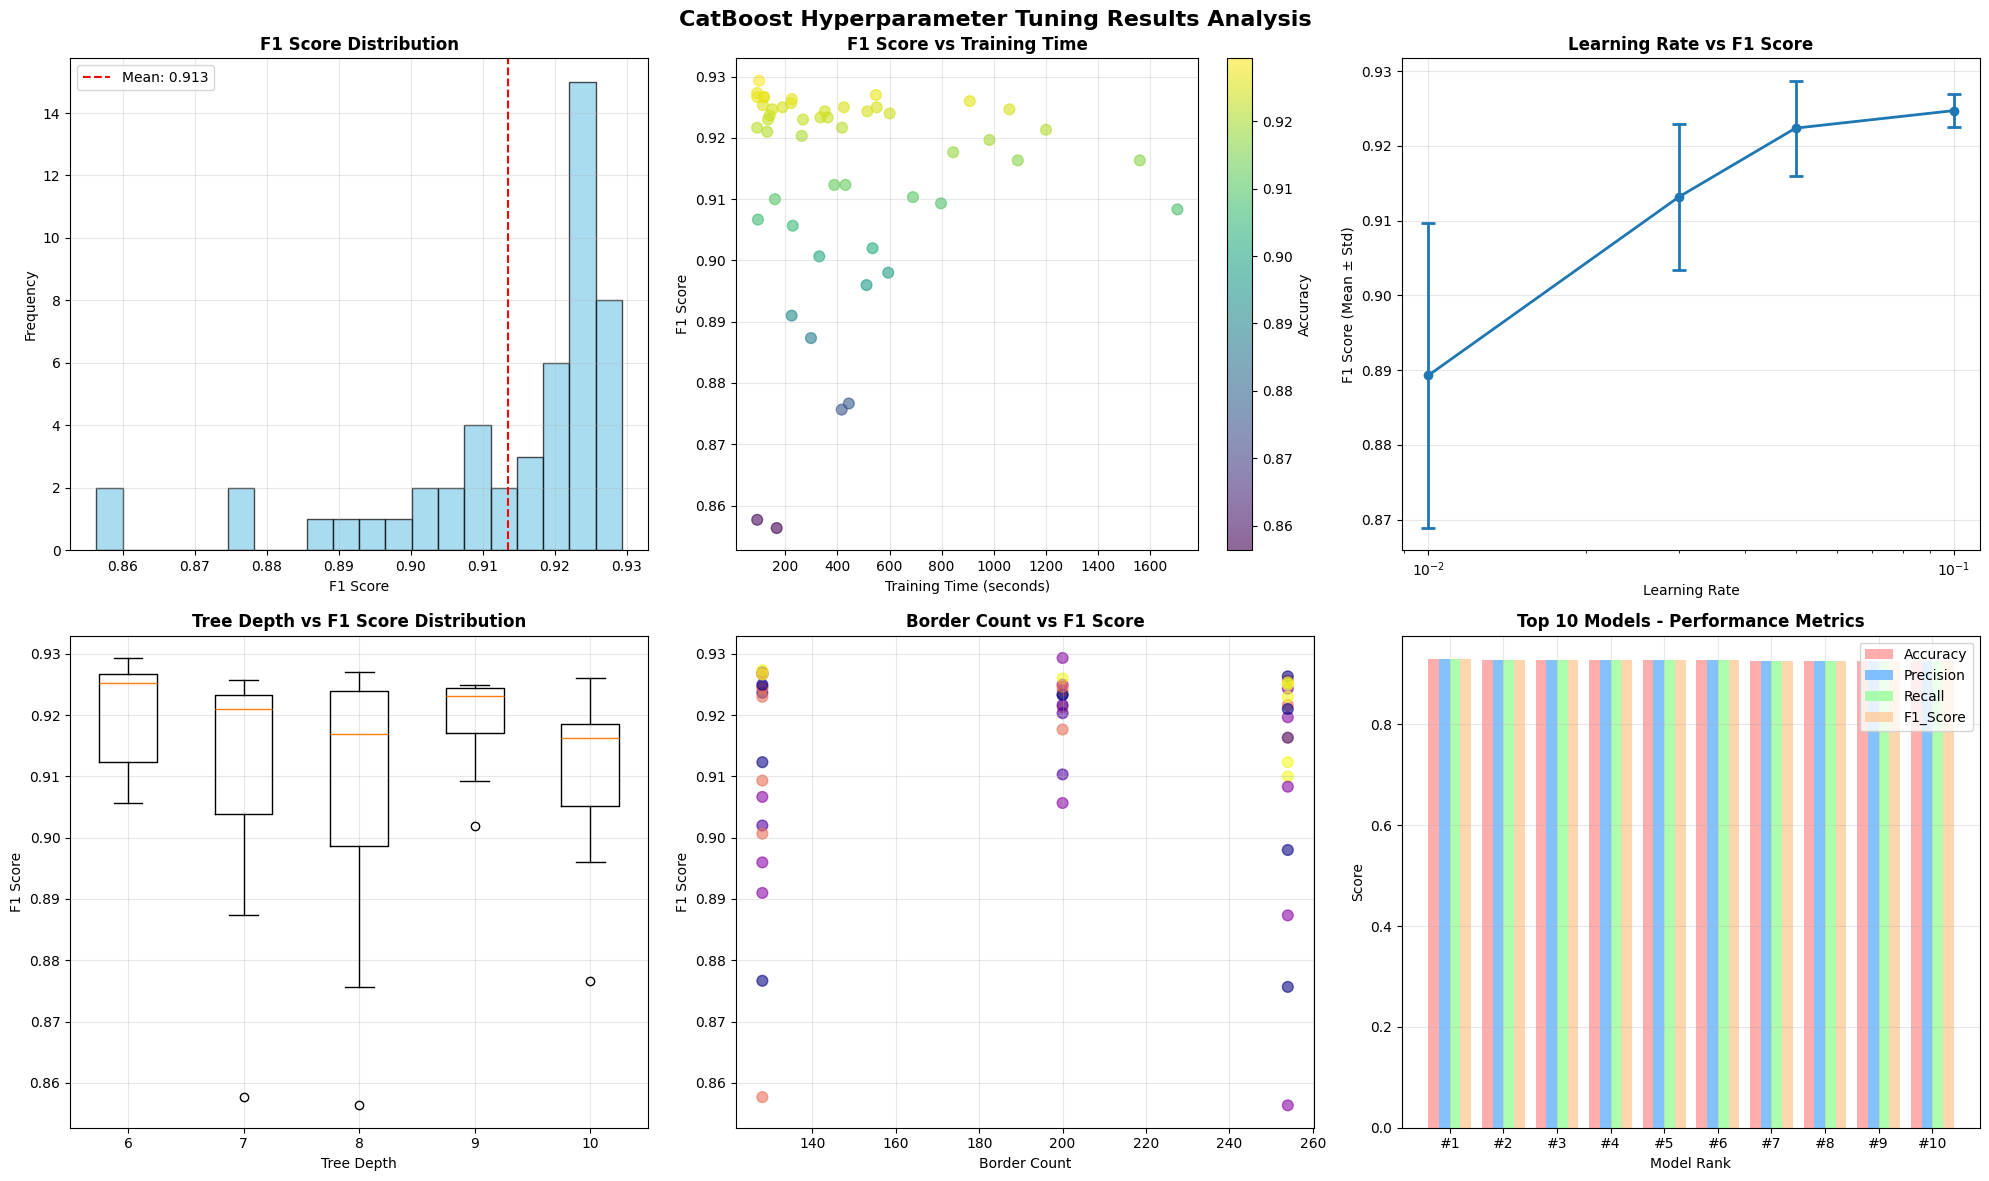


STEP 6: CHAMPION MODEL SAVING

💾 SAVING CHAMPION MODEL...
✅ CatBoost native model saved: ./best_catboost_model/champion_catboost_model.cbm
✅ Pickle model saved: ./best_catboost_model/champion_catboost_model.pkl
✅ Joblib model saved: ./best_catboost_model/champion_catboost_model.joblib
✅ Model metadata saved: ./best_catboost_model/model_metadata.json

🎉 PIPELINE EXECUTION COMPLETED!
⏱️  Total execution time: 22366.40 seconds
🏆 Champion model F1 score: 0.9293
🏆 Champion model accuracy: 0.9293
💾 Champion model saved at: ./best_catboost_model
📊 Total models evaluated: 50

✅ PIPELINE COMPLETED SUCCESSFULLY!
📊 Results stored in 'results_dataframe' variable
🏆 Champion model info stored in 'champion_model_info' variable
💾 Champion model files saved locally


In [ ]:
# ============================================================================
# EXECUTE THE COMPLETE PIPELINE
# ============================================================================

# Run the complete pipeline
print("🔥 EXECUTING CATBOOST HYPERPARAMETER TUNING PIPELINE")
print("🔥 Make sure to update the configuration in Cell 2 before running!")

results_dataframe, all_model_results, champion_model_info = execute_catboost_pipeline()

if results_dataframe is not None:
    print(f"\n✅ PIPELINE COMPLETED SUCCESSFULLY!")
    print(f"📊 Results stored in 'results_dataframe' variable")
    print(f"🏆 Champion model info stored in 'champion_model_info' variable")
    print(f"💾 Champion model files saved locally")
else:
    print(f"\n❌ Pipeline execution failed. Please check the error messages above.")


Training the Optimal Model
🥇 CHAMPION MODEL DETAILED ANALYSIS:
==================================================
🏷️  Model Name: CatBoost_CPU_19
🎯 F1 Score: 0.9293
🎯 Accuracy: 0.9293
🎯 Precision: 0.9294
🎯 Recall: 0.9293
🎯 Balanced Accuracy: 0.9293
🎯 Matthews Correlation: 0.8587
🎯 Cohen's Kappa: 0.8587
🎯 ROC AUC: 0.9796
⏱️  Training Time: 100.22 seconds

🔧 OPTIMAL HYPERPARAMETERS:
------------------------------
  iterations: 500
  learning_rate: 0.1
  depth: 6
  l2_leaf_reg: 5
  border_count: 200
  random_strength: 0
  bagging_temperature: 1
  subsample: 0.8
  colsample_bylevel: 1.0
  min_data_in_leaf: 10

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/deepfake_dataset/combined_dataset.csv")
print(f"✅ Dataset loaded successfully! Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Dataset loaded successfully! Shape: (10000, 2187)
Columns: ['file_name', 'aspect_ratio', 'bit_depth_total', 'blue_channel_kurtosis', 'blue_channel_mean', 'blue_channel_skewness', 'blue_channel_std_dev', 'canny_edge_count', 'canny_edge_density', 'color_hist_blue_0', 'color_hist_blue_1', 'color_hist_blue_10', 'color_hist_blue_11', 'color_hist_blue_12', 'color_hist_blue_13', 'color_hist_blue_14', 'color_hist_blue_15', 'color_hist_blue_16', 'color_hist_blue_17', 'color_hist_blue_18', 'color_hist_blue_19', 'color_hist_blue_2', 'color_hist_blue_20', 'color_hist_blue_21', 'color_hist_blue_22', 'color_hist_blue_23', 'color_hist_blue_24', 'color_hist_blue_25', 'color_hist_blue_26', 'color_hist_blue_27', 'color_hist_blue_28', 'color_hist_blue_29', 'color_hist_blue_3', 'color_hist_blue_30', 'color_hist_blue_31', 'color_hist_blue_4', 'color_hist_blue_5', 'color_hist_blue_6', 'color_hist_blue_7', 'color_hist_blue_8', 'color_hist_blue_9', 'color_hist_green_0', 'color_hist_green_1', 'color_hist_gre

In [ ]:
COLUMNS_TO_DROP = ['file_name', 'aspect_ratio', 'resolution']  # 👈 Update with actual columns to drop

# Specify target column (assume it's the last column if None)
TARGET_COLUMN = 'label'  # Or set to 'your_target_column'

# Train-test split configuration
TEST_SIZE = 0.3
RANDOM_STATE = 420

# Model hyperparameters (exact as provided)
MODEL_PARAMS = {
    'iterations': 500,
    'learning_rate': 0.1,
    'depth': 6,
    'l2_leaf_reg': 5,
    'border_count': 200,
    'random_strength': 0,
    'bagging_temperature': 1,
    'subsample': 0.8,
    'colsample_bylevel': 1.0,
    'min_data_in_leaf': 10,
    'task_type': 'CPU',  # As per the model name CatBoost_CPU_19
    'random_seed': RANDOM_STATE,
    'verbose': 100,  # Set to 0 for silent, 100 for progress updates
    'eval_metric': 'F1'  # Using F1 as evaluation metric
}

print("🔧 Configuration set successfully!")

🔧 Configuration set successfully!


In [ ]:
# Drop columns
original_shape = df.shape
df = df.drop(columns=COLUMNS_TO_DROP, errors='ignore')
print(f"🗑️ Dropped columns: {original_shape[1] - df.shape[1]}")
print(f"New shape: {df.shape}")

# Handle target column
if TARGET_COLUMN is None:
    TARGET_COLUMN = df.columns[-1]
print(f"🎯 Target column: {TARGET_COLUMN}")

# Separate features and target
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# Basic info
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

🗑️ Dropped columns: 3
New shape: (10000, 2184)
🎯 Target column: class
X shape: (10000, 2183)
y shape: (10000,)
Target distribution:
class
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y if y.dtype == 'object' else None  # Stratify if categorical target
)

print(f"✅ Data split completed!")
print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

✅ Data split completed!
Train: 7000 samples
Test: 3000 samples


In [ ]:
# Cell 7: Initialize and Train the Model
# ======================================
# Load (initialize) the specific CatBoost model with given hyperparameters and train it

# Initialize the model
model = CatBoostClassifier(**MODEL_PARAMS)

# Train the model
print("🏋️ Training the model...")
start_time = time.time()

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,  # Optional: Add early stopping
    verbose=MODEL_PARAMS['verbose']
)

training_time = time.time() - start_time
print(f"✅ Training completed in {training_time:.2f} seconds!")


🏋️ Training the model...
0:	learn: 0.7876106	test: 0.7811540	best: 0.7811540 (0)	total: 954ms	remaining: 7m 55s
100:	learn: 0.9847630	test: 0.9270620	best: 0.9274276 (99)	total: 53.6s	remaining: 3m 31s
200:	learn: 0.9988704	test: 0.9321453	best: 0.9338815 (188)	total: 1m 45s	remaining: 2m 37s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9338814663
bestIteration = 188

Shrink model to first 189 iterations.
✅ Training completed in 127.00 seconds!


In [ ]:
# Cell 8: Evaluate the Model
# ===========================
# Make predictions and compute metrics

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n📊 Model Evaluation Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
print("\n📋 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\n📑 Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance (optional)
print("\n⭐ Top 10 Feature Importances:")
importances = pd.Series(model.get_feature_importance(), index=X.columns)
print(importances.sort_values(ascending=False).head(10))



📊 Model Evaluation Results:
Accuracy: 0.9357
Precision: 0.9357
Recall: 0.9357
F1 Score: 0.9357

📋 Confusion Matrix:
[[1444   97]
 [  96 1363]]

📑 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1541
           1       0.93      0.93      0.93      1459

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000


⭐ Top 10 Feature Importances:
freq_domain_high_energy         6.649494
deep_embed_1471                 6.273887
red_channel_mean                3.914210
deep_embed_169                  2.642513
color_hist_blue_0               1.934050
haralick_texture_correlation    1.782988
deep_embed_1345                 1.675840
deep_embed_439                  1.644044
color_hist_green_0              1.640255
deep_embed_1662                 1.505883
dtype: float64


In [ ]:
# Cell 9: Save the Trained Model
# ==============================
# Save the model for future use

model_save_path = '/content/drive/MyDrive/deepfake_dataset/trained_catboost_model.cbm'
model.save_model(model_save_path)
print(f"💾 Model saved to: {model_save_path}")

# Download the model file
files.download(model_save_path)
print("✅ Model downloaded successfully!")


💾 Model saved to: /content/drive/MyDrive/deepfake_dataset/trained_catboost_model.cbm


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded successfully!


# Testing

In [ ]:
real_df = pd.read_csv('/content/drive/MyDrive/deepfake_dataset/real_testset_features_20250722_141854.csv')
fake_df = pd.read_csv('/content/drive/MyDrive/deepfake_dataset/fake_testset_features_20250722_135742.csv')

real_df['label'] = 1
fake_df['label'] = 0

COLUMNS_TO_DROP = ['file_name', 'aspect_ratio', 'resolution']  # 👈 Update with actual columns to drop

# Specify target column (assume it's the last column if None)
TARGET_COLUMN = 'label'  # Or set to 'your_target_column'

test_df = pd.concat([real_df, fake_df], ignore_index=True)

test_df.to_csv('/content/drive/MyDrive/deepfake_dataset/testset.csv', index=False)

#test_df = test_df.drop(columns=COLUMNS_TO_DROP, errors='ignore')
# Display the first few rows and info of the combined dataframe

print("Test DataFrame Head:")
print(test_df.head())
print("\nTest DataFrame Info:")
test_df.info()

In [ ]:
model = CatBoostClassifier()
model.load_model('/content/drive/MyDrive/deepfake_dataset/trained_catboost_model.cbm')

In [ ]:
test_df = pd.read_csv('/content/drive/MyDrive/deepfake_dataset/testset.csv')
'''
X, y = load_and_preprocess_data_small(file_path='/content/drive/MyDrive/deepfake_dataset/testset.csv', target_column_name='label', columns_to_drop=COLUMNS_TO_DROP)
if X is None:
  print("❌ Pipeline failed at data loading stage")
'''
print(test_df.head())

       file_name  aspect_ratio  bit_depth_total  blue_channel_kurtosis  \
0  0000 (10).jpg           1.0             24.0                  -0.62   
1   0000 (2).jpg           1.0             24.0                   1.15   
2   0000 (3).jpg           1.0             24.0                   0.91   
3   0000 (4).jpg           1.0             24.0                  -0.25   
4   0000 (5).jpg           1.0             24.0                   1.23   

   blue_channel_mean  blue_channel_skewness  blue_channel_std_dev  \
0             127.70                   0.17                 61.48   
1              59.20                   1.44                 62.84   
2             100.87                   0.11                 41.34   
3             104.63                   0.40                 48.88   
4             107.86                   0.02                 18.81   

   canny_edge_count  canny_edge_density  color_hist_blue_0  ...  \
0             308.0              0.3008                3.0  ...   
1     

In [ ]:
test_df['freq_domain_high_energy'] = 0
test_df['freq_domain_low_energy'] = 0
test_df['freq_domain_mid_energy'] = 0
print(f"✅ Dataset loaded successfully! Shape: {test_df.shape}")
print(f"Columns: {test_df.columns.tolist()}")

✅ Dataset loaded successfully! Shape: (20000, 2184)
Columns: ['bit_depth_total', 'blue_channel_kurtosis', 'blue_channel_mean', 'blue_channel_skewness', 'blue_channel_std_dev', 'canny_edge_count', 'canny_edge_density', 'color_hist_blue_0', 'color_hist_blue_1', 'color_hist_blue_10', 'color_hist_blue_11', 'color_hist_blue_12', 'color_hist_blue_13', 'color_hist_blue_14', 'color_hist_blue_15', 'color_hist_blue_16', 'color_hist_blue_17', 'color_hist_blue_18', 'color_hist_blue_19', 'color_hist_blue_2', 'color_hist_blue_20', 'color_hist_blue_21', 'color_hist_blue_22', 'color_hist_blue_23', 'color_hist_blue_24', 'color_hist_blue_25', 'color_hist_blue_26', 'color_hist_blue_27', 'color_hist_blue_28', 'color_hist_blue_29', 'color_hist_blue_3', 'color_hist_blue_30', 'color_hist_blue_31', 'color_hist_blue_4', 'color_hist_blue_5', 'color_hist_blue_6', 'color_hist_blue_7', 'color_hist_blue_8', 'color_hist_blue_9', 'color_hist_green_0', 'color_hist_green_1', 'color_hist_green_10', 'color_hist_green_11'

In [ ]:
TARGET_COLUMN = 'label'
COLUMNS_TO_DROP = ['file_name', 'aspect_ratio', 'resolution']  # 👈 Update with actual columns to drop
original_test_shape = test_df.shape
test_df = test_df.drop(columns=COLUMNS_TO_DROP, errors='ignore')
print(f"🗑️ Dropped columns: {original_test_shape[1] - test_df.shape[1]}")
print(f"New test shape: {test_df.shape}")

🗑️ Dropped columns: 0
New test shape: (20000, 2184)


In [ ]:
# Handle target column (assume same as training)
if TARGET_COLUMN is None:
    TARGET_COLUMN = test_df.columns[-1]  # Or set explicitly if different
print(f"🎯 Target column for test: {TARGET_COLUMN}")

# Separate features and target
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(X_test.head())
print(y_test.head())
print(f"Columns: {X_test.columns.tolist()}")


🎯 Target column for test: label
   bit_depth_total  blue_channel_kurtosis  blue_channel_mean  \
0             24.0                  -0.62             127.70   
1             24.0                   1.15              59.20   
2             24.0                   0.91             100.87   
3             24.0                  -0.25             104.63   
4             24.0                   1.23             107.86   

   blue_channel_skewness  blue_channel_std_dev  canny_edge_count  \
0                   0.17                 61.48             308.0   
1                   1.44                 62.84             253.0   
2                   0.11                 41.34             169.0   
3                   0.40                 48.88             283.0   
4                   0.02                 18.81              62.0   

   canny_edge_density  color_hist_blue_0  color_hist_blue_1  \
0              0.3008                3.0               11.0   
1              0.2471              142.0        

In [ ]:
X_test_copy = X_test.copy()
print(X_test_copy.head())
print(X_test_copy.shape)

   bit_depth_total  blue_channel_kurtosis  blue_channel_mean  \
0             24.0                  -0.62             127.70   
1             24.0                   1.15              59.20   
2             24.0                   0.91             100.87   
3             24.0                  -0.25             104.63   
4             24.0                   1.23             107.86   

   blue_channel_skewness  blue_channel_std_dev  canny_edge_count  \
0                   0.17                 61.48             308.0   
1                   1.44                 62.84             253.0   
2                   0.11                 41.34             169.0   
3                   0.40                 48.88             283.0   
4                   0.02                 18.81              62.0   

   canny_edge_density  color_hist_blue_0  color_hist_blue_1  \
0              0.3008                3.0               11.0   
1              0.2471              142.0              130.0   
2              0.

In [ ]:
search_value = "0010 (10).jpg"
value_exists = X_test_copy.isin([search_value]).any().any()

if value_exists:
    print(f"The value '{search_value}' exists in the DataFrame.")
else:
    print(f"The value '{search_value}' does not exist in the DataFrame.")

The value '0010 (10).jpg' exists in the DataFrame.


In [ ]:
boolean_mask = X_test_copy == search_value

# Use .any() to identify columns that have at least one True value (i.e., contain the target value)
columns_with_value = boolean_mask.any()

# Extract the names of the columns
column_names = columns_with_value[columns_with_value].index.tolist()

print(f"The value {search_value} is present in the following columns: {column_names}")

print(X_test_copy['deep_embed_999'])

The value 0010 (10).jpg is present in the following columns: ['deep_embed_999']
0        0.9958024024963379
1        0.4539589285850525
2        1.2949261665344238
3        2.3429532051086426
4                       0.0
                ...        
19995           999 (6).jpg
19996           999 (7).jpg
19997           999 (8).jpg
19998           999 (9).jpg
19999               999.jpg
Name: deep_embed_999, Length: 20000, dtype: object


In [ ]:
X_test = X_test_copy.drop(columns='deep_embed_999', errors='ignore')
print(X_test.columns.tolist())

['bit_depth_total', 'blue_channel_kurtosis', 'blue_channel_mean', 'blue_channel_skewness', 'blue_channel_std_dev', 'canny_edge_count', 'canny_edge_density', 'color_hist_blue_0', 'color_hist_blue_1', 'color_hist_blue_10', 'color_hist_blue_11', 'color_hist_blue_12', 'color_hist_blue_13', 'color_hist_blue_14', 'color_hist_blue_15', 'color_hist_blue_16', 'color_hist_blue_17', 'color_hist_blue_18', 'color_hist_blue_19', 'color_hist_blue_2', 'color_hist_blue_20', 'color_hist_blue_21', 'color_hist_blue_22', 'color_hist_blue_23', 'color_hist_blue_24', 'color_hist_blue_25', 'color_hist_blue_26', 'color_hist_blue_27', 'color_hist_blue_28', 'color_hist_blue_29', 'color_hist_blue_3', 'color_hist_blue_30', 'color_hist_blue_31', 'color_hist_blue_4', 'color_hist_blue_5', 'color_hist_blue_6', 'color_hist_blue_7', 'color_hist_blue_8', 'color_hist_blue_9', 'color_hist_green_0', 'color_hist_green_1', 'color_hist_green_10', 'color_hist_green_11', 'color_hist_green_12', 'color_hist_green_13', 'color_hist_g

In [ ]:
# Basic info
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Test target distribution:\n{y_test.value_counts()}")

# Additional preprocessing if needed (e.g., handle missing values similarly to training)
# Assuming same as training: fill numerical with median, categorical with 'Unknown'
print("\n🔧 Handling missing values in test data...")
numerical_cols = X_test.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if X_test[col].isnull().sum() > 0:
        # Use training median if available, but since we don't have it, use test median
        X_test[col].fillna(X_test[col].median(), inplace=True)

object_cols = X_test.select_dtypes(include=['object']).columns
for col in object_cols:
    if X_test[col].isnull().sum() > 0:
        X_test[col].fillna('Unknown', inplace=True)

print("✅ Test data preprocessing completed!")

print(y_test.head())
print(X_test.head())

X_test shape: (20000, 2182)
y_test shape: (20000,)
Test target distribution:
label
1    10000
0    10000
Name: count, dtype: int64

🔧 Handling missing values in test data...
✅ Test data preprocessing completed!
0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64
   bit_depth_total  blue_channel_kurtosis  blue_channel_mean  \
0             24.0                  -0.62             127.70   
1             24.0                   1.15              59.20   
2             24.0                   0.91             100.87   
3             24.0                  -0.25             104.63   
4             24.0                   1.23             107.86   

   blue_channel_skewness  blue_channel_std_dev  canny_edge_count  \
0                   0.17                 61.48             308.0   
1                   1.44                 62.84             253.0   
2                   0.11                 41.34             169.0   
3                   0.40                 48.88             283.0   
4  

In [ ]:
# Cell 14: Run Predictions on Test Set
# ====================================
# Make predictions using the loaded model

print("🔮 Making predictions on test set...")
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("✅ Predictions completed!")
print(f"Sample predictions: {y_pred[:]}")


🔮 Making predictions on test set...
✅ Predictions completed!
Sample predictions: [0 0 0 ... 1 0 1]


In [ ]:
# Cell 15: Evaluate and Print Results
# ===================================
# Compute and print evaluation metrics

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n📊 Test Set Evaluation Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
print("\n📋 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Classification Report
print("\n📑 Classification Report:")
print(classification_report(y_test, y_pred))



📊 Test Set Evaluation Results:
Accuracy: 0.4338
Precision: 0.4308
Recall: 0.4338
F1 Score: 0.4275

📋 Confusion Matrix:
[[5386 4614]
 [6710 3290]]

📑 Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.54      0.49     10000
           1       0.42      0.33      0.37     10000

    accuracy                           0.43     20000
   macro avg       0.43      0.43      0.43     20000
weighted avg       0.43      0.43      0.43     20000



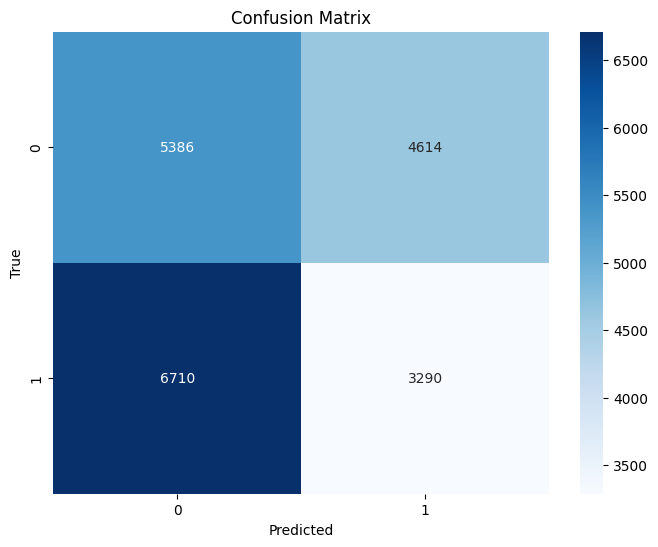

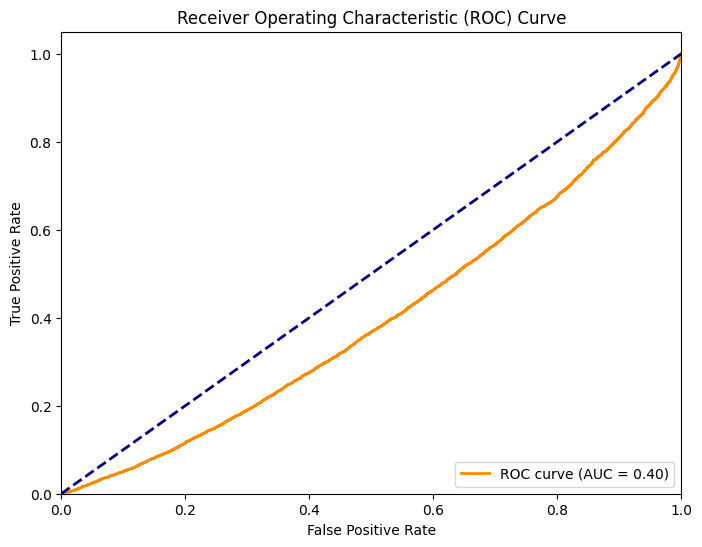

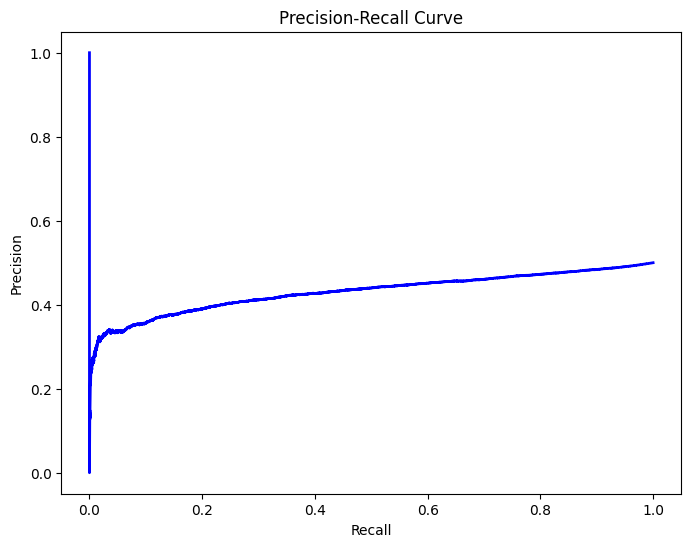


⭐ Feature Importance Visualization:


ValueError: Length of values (2183) does not match length of index (2182)

In [ ]:
# Cell 16: Visualize Results
# ==========================
# Visualize confusion matrix and other relevant plots

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Function to plot confusion matrix
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Get unique class names (assuming y_test is categorical or encoded)
class_names = sorted(np.unique(y_test))

# Plot confusion matrix
plot_confusion_matrix(cm, class_names)

# If binary classification, plot ROC Curve
n_classes = len(class_names)
if n_classes == 2:
    # Binarize y_test for binary case
    y_test_bin = label_binarize(y_test, classes=class_names)
    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_proba[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin, y_pred_proba[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(recall_curve, precision_curve, color='blue', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()
elif n_classes > 2:
    print("⚠️ ROC and Precision-Recall curves shown for binary classification only. For multi-class, consider one-vs-rest plots.")

# Feature Importance Visualization
print("\n⭐ Feature Importance Visualization:")
# Drop the problematic column from X_test before getting feature names
X_test_for_importance = X_test.drop(columns='deep_embed_999', errors='ignore')
importances = pd.Series(model.get_feature_importance(), index=X_test_for_importance.columns)
importances_sorted = importances.sort_values(ascending=False).head(20)  # Top 20 features

plt.figure(figsize=(10, 8))
importances_sorted.plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.show()

print("✅ Visualizations completed!")